In [1]:
from pathlib import Path
IMG_EXT = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

def show_tree(folder, depth=0, max_depth=4):
    folder = Path(folder)
    n = sum(1 for f in folder.rglob("*") if f.suffix.lower() in IMG_EXT)
    print("    " * depth + f"{folder.name}/  ({n} images)")
    if depth < max_depth:
        for sub in sorted(p for p in folder.iterdir() if p.is_dir()):
            show_tree(sub, depth + 1, max_depth)

show_tree("/kaggle/input")

input/  (32 images)
    datasets/  (32 images)
        bhanukachamindu/  (32 images)
            unseen-colour/  (32 images)
                Unseen_Test_Images_Colour/  (32 images)
    models/  (0 images)
        bhanukachamindu/  (0 images)
            colourtn/  (0 images)
                other/  (0 images)


In [2]:
import os, sys, random, hashlib, math, time, copy, subprocess
from pathlib import Path
import numpy as np
try:
    import timm
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "timm"], check=True)
    import timm
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision.transforms as T
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from concurrent.futures import ThreadPoolExecutor

import pandas as pd

# ---------------- SETTINGS (leave None to find automatically) ----------------
MODEL_PATH  = None      # the .pt model file saved by the training notebook
UNSEEN_DIR  = None      # folder holding the unseen photos in class folders
TRAIN_DIR   = None      # optional: the training dataset (only for the copy check, or for the baseline below)
UNSEEN_RENAME = {}      # only if the unseen folder names differ from the model classes, e.g. {"rust": "aloe_rust"} (lowercase)
PREFIX = "colour"                        # the model file name starts with this
POS_CLASS = "green"                  # used for the extra two-group check
POS_NAMES = ("good", "not good")
USE_TTA = True          # average the prediction of the photo, its horizontal flip and its vertical flip
BATCH = 32
SEED = 42
OUT_DIR = "/kaggle/working"
SEARCH_ROOTS = ["/kaggle/input", "/kaggle/working"]
# -----------------------------------------------------------------------------

IMG_EXT = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print("torch", torch.__version__, "| timm", timm.__version__, "| device:", DEVICE)

torch 2.10.0+cpu | timm 1.0.26 | device: cpu


In [3]:
SPLIT_NAMES = {"train", "training", "val", "valid", "validation", "test", "testing"}

def norm(name):
    return name.strip().lower().replace("-", "_").replace(" ", "_")

def list_images(root):
    """All images under root. The class of a photo = name of the folder it sits in (lowercased)."""
    root = Path(root)
    assert root.exists(), f"Folder not found: {root}  (is the dataset added under Input? run the tree cell above)"
    paths, labels = [], []
    for f in sorted(root.rglob("*")):
        if f.is_file() and f.suffix.lower() in IMG_EXT:
            cls = norm(f.parent.name)
            if cls in SPLIT_NAMES:
                continue
            paths.append(str(f)); labels.append(cls)
    return paths, labels

def find_files(pattern):
    out = []
    for root in SEARCH_ROOTS:
        if Path(root).exists():
            out += [p for p in Path(root).rglob(pattern) if p.is_file()]
    return out

if MODEL_PATH is None:
    found = [p for p in find_files("*.pt") if p.name.startswith(PREFIX + "_tresnet")]
    assert found, "No TResNet .pt model found under /kaggle/input or /kaggle/working. Add the training notebook (or its zip as a dataset) as an input, or set MODEL_PATH."
    found = sorted(found, key=lambda p: p.stat().st_mtime, reverse=True)
    if len(found) > 1:
        print("Several models found. The newest is used; set MODEL_PATH to choose another one:")
        for p in found:
            print("   ", p)
    MODEL_PATH = str(found[0])

ckpt = torch.load(MODEL_PATH, map_location="cpu", weights_only=False)
CLASSES = [norm(c) for c in ckpt["classes"]]
class_to_idx = {c: i for i, c in enumerate(CLASSES)}
K = len(CLASSES); IDX = list(range(K))
IMG_SIZE, RES = ckpt["img_size"], ckpt["res"]
MEAN, STD = tuple(ckpt["mean"]), tuple(ckpt["std"])

model = timm.create_model(ckpt["model_name"], pretrained=False, num_classes=K)
model.load_state_dict(ckpt["state_dict"])
model = model.to(DEVICE).to(memory_format=torch.channels_last).eval()

used_file = Path(MODEL_PATH).with_name(Path(MODEL_PATH).stem + "_unseen_used_for_training.txt")
used_for_training = set(used_file.read_text().split("\n")) - {""} if used_file.exists() else set()

print("model :", MODEL_PATH)
print("architecture:", ckpt["model_name"], "| input size:", IMG_SIZE)
print("model classes:", CLASSES)
print("unseen photos used for training by the training notebook:", len(used_for_training))

model : /kaggle/input/models/bhanukachamindu/colourtn/other/default/1/colour_tresnet_m.pt
architecture: tresnet_m.miil_in21k_ft_in1k | input size: 224
model classes: ['brown', 'green', 'yellow']
unseen photos used for training by the training notebook: 0


In [4]:
def n_images(d):
    return sum(1 for f in Path(d).rglob("*") if f.suffix.lower() in IMG_EXT)

def find_candidates(class_names, min_match=2):
    """Folders under /kaggle/input whose sub-folders match at least min_match of the class names."""
    found = []
    for dirpath, dirnames, _ in os.walk("/kaggle/input"):
        if len({norm(d) for d in dirnames} & set(class_names)) >= min_match:
            found.append(dirpath)
            dirnames[:] = []            # do not look inside
    return found

cands = find_candidates(CLASSES, min_match=min(2, K))
if UNSEEN_DIR is None:
    unseen_c = [d for d in cands if "unseen" in d.lower()]
    if len(unseen_c) == 1:
        UNSEEN_DIR = unseen_c[0]
    elif not unseen_c and len(cands) == 1:
        UNSEEN_DIR = cands[0]
    else:
        print("Folders that look like photo sets:", cands)
        raise AssertionError("Could not decide which folder holds the unseen photos. Set UNSEEN_DIR in the settings cell.")
if TRAIN_DIR is None:
    others = [d for d in cands if d != UNSEEN_DIR and "unseen" not in d.lower() and not d.startswith(str(UNSEEN_DIR))]
    TRAIN_DIR = max(others, key=n_images) if others else None

un_paths, un_labels = list_images(UNSEEN_DIR)
un_labels = [UNSEEN_RENAME.get(l, l) for l in un_labels]
assert un_paths, f"No images found in {UNSEEN_DIR}"
assert set(un_labels) <= set(CLASSES), (f"Unseen class names {sorted(set(un_labels) - set(CLASSES))} are not among the model classes {CLASSES}. "
                                        "Fix the folder names or fill in UNSEEN_RENAME in the settings cell.")
keep = [k for k, (p, l) in enumerate(zip(un_paths, un_labels)) if f"{l}/{Path(p).name}" not in used_for_training]
print(f"{len(un_paths) - len(keep)} unseen photos were used for training and are left out.")
un_paths = [un_paths[k] for k in keep]; un_labels = [un_labels[k] for k in keep]
y_u = np.array([class_to_idx[l] for l in un_labels])

print("Unseen folder  :", UNSEEN_DIR)
print("Unseen photos  :", {c: un_labels.count(c) for c in CLASSES if c in un_labels}, "| total", len(un_paths))
print("Training folder:", TRAIN_DIR or "not attached (optional)")
if len(un_paths) < 60:
    print(f"\nNote: with {len(un_paths)} photos one mistake moves the accuracy by about {100 / len(un_paths):.1f}%. Treat the result as a first indication, not a final score.")

0 unseen photos were used for training and are left out.
Unseen folder  : /kaggle/input/datasets/bhanukachamindu/unseen-colour/Unseen_Test_Images_Colour
Unseen photos  : {'brown': 8, 'green': 11, 'yellow': 13} | total 32
Training folder: not attached (optional)

Note: with 32 photos one mistake moves the accuracy by about 3.1%. Treat the result as a first indication, not a final score.


In [5]:
def md5(p):
    with open(p, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

def ahash(p):
    im = Image.open(p).convert("L").resize((8, 8), Image.BILINEAR)
    a = np.asarray(im, dtype=float)
    return "".join("1" if v else "0" for v in (a > a.mean()).ravel())

if TRAIN_DIR:
    tr_paths, _ = list_images(TRAIN_DIR)
    tr_md5 = {md5(p) for p in tr_paths}
    tr_ah = {ahash(p) for p in tr_paths}
    exact = sum(md5(p) in tr_md5 for p in un_paths)
    near = sum(ahash(p) in tr_ah for p in un_paths)
    print(f"{exact} exact copies | {near} exact-or-near copies of a training photo (out of {len(un_paths)} unseen photos)")
else:
    print("Training dataset not attached: skipped.")

Training dataset not attached: skipped.


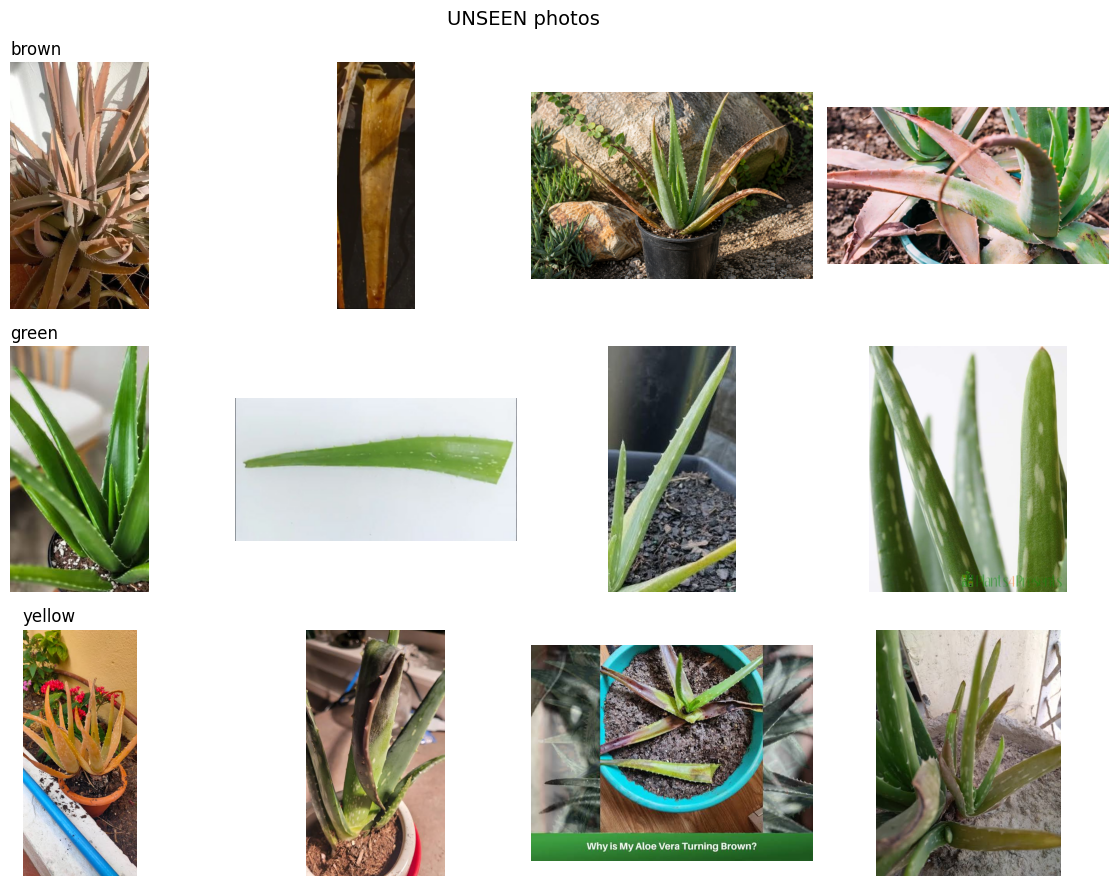

In [6]:
def show_samples(paths, labels, title, n=4, max_classes=8):
    cls = sorted(set(labels))[:max_classes]
    fig, axes = plt.subplots(len(cls), n, figsize=(3 * n, 3 * len(cls)), squeeze=False)
    rng = random.Random(1)
    for ax in axes.ravel():
        ax.axis("off")
    for r, c in enumerate(cls):
        pool = [p for p, l in zip(paths, labels) if l == c]
        for k, p in enumerate(rng.sample(pool, min(n, len(pool)))):
            axes[r][k].imshow(Image.open(p).convert("RGB"))
            if k == 0:
                axes[r][k].set_title(c, loc="left", fontsize=12)
    fig.suptitle(title, fontsize=14)
    plt.tight_layout(); plt.show()

show_samples(un_paths, un_labels, "UNSEEN photos")
if TRAIN_DIR:
    _p, _l = list_images(TRAIN_DIR)
    show_samples(_p, _l, "TRAINING photos (for comparison)")

accuracy without / with flip averaging: 59.38% / 56.25%

===== UNSEEN photos (with flip averaging): accuracy 56.25% | macro F1 0.418 =====

              precision    recall  f1-score   support

       brown      0.000     0.000     0.000         8
       green      0.833     0.455     0.588        11
      yellow      0.500     1.000     0.667        13

    accuracy                          0.562        32
   macro avg      0.444     0.485     0.418        32
weighted avg      0.490     0.562     0.473        32

How often each class really occurs vs how often the model predicts it
(one class predicted far more than it occurs = the model is falling back on it):
  brown                     true    8 | predicted    0
  green                     true   11 | predicted    6
  yellow                    true   13 | predicted   26

Most common mix-ups (count: true -> predicted):
     7: brown -> yellow
     6: green -> yellow
     1: brown -> green

confusion matrix (rows = true, columns = p

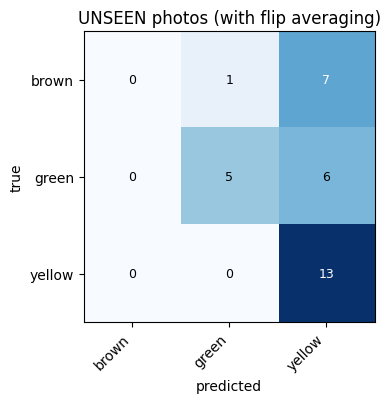


Good vs not good accuracy: 78.12%
'not good' photos called GOOD: 1 of 21
'good' photos called NOT GOOD: 6 of 11
(Always answering 'not good' would score 65.6%)

Average confidence: 79% when right | 77% when wrong

If the app only answers when the model is confident (otherwise it says 'not sure'):
  confidence >= 0.50: answers  93.8% of the photos | accuracy on those  56.7%
  confidence >= 0.60: answers  90.6% of the photos | accuracy on those  58.6%
  confidence >= 0.70: answers  71.9% of the photos | accuracy on those  56.5%
  confidence >= 0.80: answers  56.2% of the photos | accuracy on those  61.1%
  confidence >= 0.90: answers  21.9% of the photos | accuracy on those  71.4%
  confidence >= 0.95: answers   3.1% of the photos | accuracy on those 100.0%

Per photo (all):
✗  brown_0001.jpeg                          true=brown              pred=yellow             (84%)
✗  brown_0002.jpg                           true=brown              pred=yellow             (88%)
✗  brown_0003.jpg  

In [7]:
def load_rgb(p):
    """Open a photo, respect the phone's rotation flag, and resize to RES x RES (kept in memory as uint8)."""
    im = ImageOps.exif_transpose(Image.open(p)).convert("RGB")
    return np.asarray(im.resize((RES, RES), Image.BICUBIC))

def load_all(paths):
    with ThreadPoolExecutor(8) as ex:
        return np.stack(list(ex.map(load_rgb, paths)))

def plot_cm(cm, title):
    size = max(4.6, 0.65 * K + 2.5)
    fig, ax = plt.subplots(figsize=(size, size * 0.9))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(IDX); ax.set_xticklabels(CLASSES, rotation=45, ha="right")
    ax.set_yticks(IDX); ax.set_yticklabels(CLASSES)
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(title)
    for i in IDX:
        for j in IDX:
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=9,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.tight_layout(); plt.show()

def binary_check(y, pred):
    if POS_CLASS not in class_to_idx:
        return
    a, b = POS_NAMES
    g = class_to_idx[POS_CLASS]
    t, p = (y == g), (pred == g)
    print(f"\n{a.capitalize()} vs {b} accuracy: {(t == p).mean() * 100:.2f}%")
    print(f"'{b}' photos called {a.upper()}: {int(((~t) & p).sum())} of {int((~t).sum())}")
    print(f"'{a}' photos called {b.upper()}: {int((t & ~p).sum())} of {int(t.sum())}")
    print(f"(Always answering '{b}' would score {(~t).mean() * 100:.1f}%)")

def report(y, pred, name):
    """Accuracy, per-class report, how often each class is predicted, main mix-ups, confusion matrix."""
    acc = accuracy_score(y, pred)
    f1 = f1_score(y, pred, average="macro", labels=sorted(set(y)), zero_division=0)
    print(f"\n===== {name}: accuracy {acc * 100:.2f}% | macro F1 {f1:.3f} =====\n")
    print(classification_report(y, pred, labels=IDX, target_names=CLASSES, digits=3, zero_division=0))
    print("How often each class really occurs vs how often the model predicts it")
    print("(one class predicted far more than it occurs = the model is falling back on it):")
    for i, c in enumerate(CLASSES):
        print(f"  {c:25s} true {int((y == i).sum()):4d} | predicted {int((pred == i).sum()):4d}")
    cm = confusion_matrix(y, pred, labels=IDX)
    pairs = sorted(((cm[i, j], CLASSES[i], CLASSES[j]) for i in IDX for j in IDX if i != j and cm[i, j] > 0), reverse=True)[:8]
    if pairs:
        print("\nMost common mix-ups (count: true -> predicted):")
        for n, a, b in pairs:
            print(f"  {n:4d}: {a} -> {b}")
    print("\nconfusion matrix (rows = true, columns = predicted):", CLASSES)
    print(cm)
    plot_cm(cm, name)
    binary_check(y, pred)
    return acc, f1

eval_tf = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE), interpolation=T.InterpolationMode.BICUBIC), T.ToTensor(), T.Normalize(MEAN, STD)])
arr_u = load_all(un_paths)

@torch.no_grad()
def predict(arr, tta):
    out = []
    for i in range(0, len(arr), BATCH):
        x = torch.stack([eval_tf(Image.fromarray(a)) for a in arr[i:i + BATCH]]).to(DEVICE).contiguous(memory_format=torch.channels_last)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
            p = model(x).float().softmax(1)
            if tta:
                p = (p + model(torch.flip(x, dims=[3])).float().softmax(1) + model(torch.flip(x, dims=[2])).float().softmax(1)) / 3
        out.append(p.cpu())
    return torch.cat(out).numpy()

probs_plain = predict(arr_u, tta=False)
probs_tta = predict(arr_u, tta=True)
probs_u = probs_tta if USE_TTA else probs_plain
pred_u = probs_u.argmax(1)
print(f"accuracy without / with flip averaging: {accuracy_score(y_u, probs_plain.argmax(1)) * 100:.2f}% / {accuracy_score(y_u, probs_tta.argmax(1)) * 100:.2f}%")
unseen_acc, unseen_f1 = report(y_u, pred_u, "UNSEEN photos" + (" (with flip averaging)" if USE_TTA else ""))

conf = probs_u.max(1)
ok = pred_u == y_u
print("\nAverage confidence:", " | ".join(t for t in (f"{conf[ok].mean() * 100:.0f}% when right" if ok.any() else "",
                                                     f"{conf[~ok].mean() * 100:.0f}% when wrong" if (~ok).any() else "") if t))
print("\nIf the app only answers when the model is confident (otherwise it says 'not sure'):")
for thr in (0.5, 0.6, 0.7, 0.8, 0.9, 0.95):
    m = conf >= thr
    if m.any():
        print(f"  confidence >= {thr:.2f}: answers {m.mean() * 100:5.1f}% of the photos | accuracy on those {np.mean(pred_u[m] == y_u[m]) * 100:5.1f}%")

print(f"\nPer photo ({'all' if len(y_u) <= 60 else 'wrong ones only'}):")
for p, t, pr, pb in zip(un_paths, y_u, pred_u, conf):
    if len(y_u) <= 60 or t != pr:
        print(f"{'✓' if t == pr else '✗'}  {Path(p).name[:40]:40s} true={CLASSES[t]:18s} pred={CLASSES[pr]:18s} ({pb * 100:.0f}%)")

df = pd.DataFrame({"file": [Path(p).name for p in un_paths], "true": [CLASSES[i] for i in y_u],
                   "predicted": [CLASSES[i] for i in pred_u], "correct": pred_u == y_u, "confidence": conf.round(3)})
for i, c in enumerate(CLASSES):
    df[f"p_{c}"] = probs_u[:, i].round(3)
csv_path = f"{OUT_DIR}/{PREFIX}_tresnet_unseen_predictions.csv"
df.to_csv(csv_path, index=False)
print("\nsaved:", csv_path)

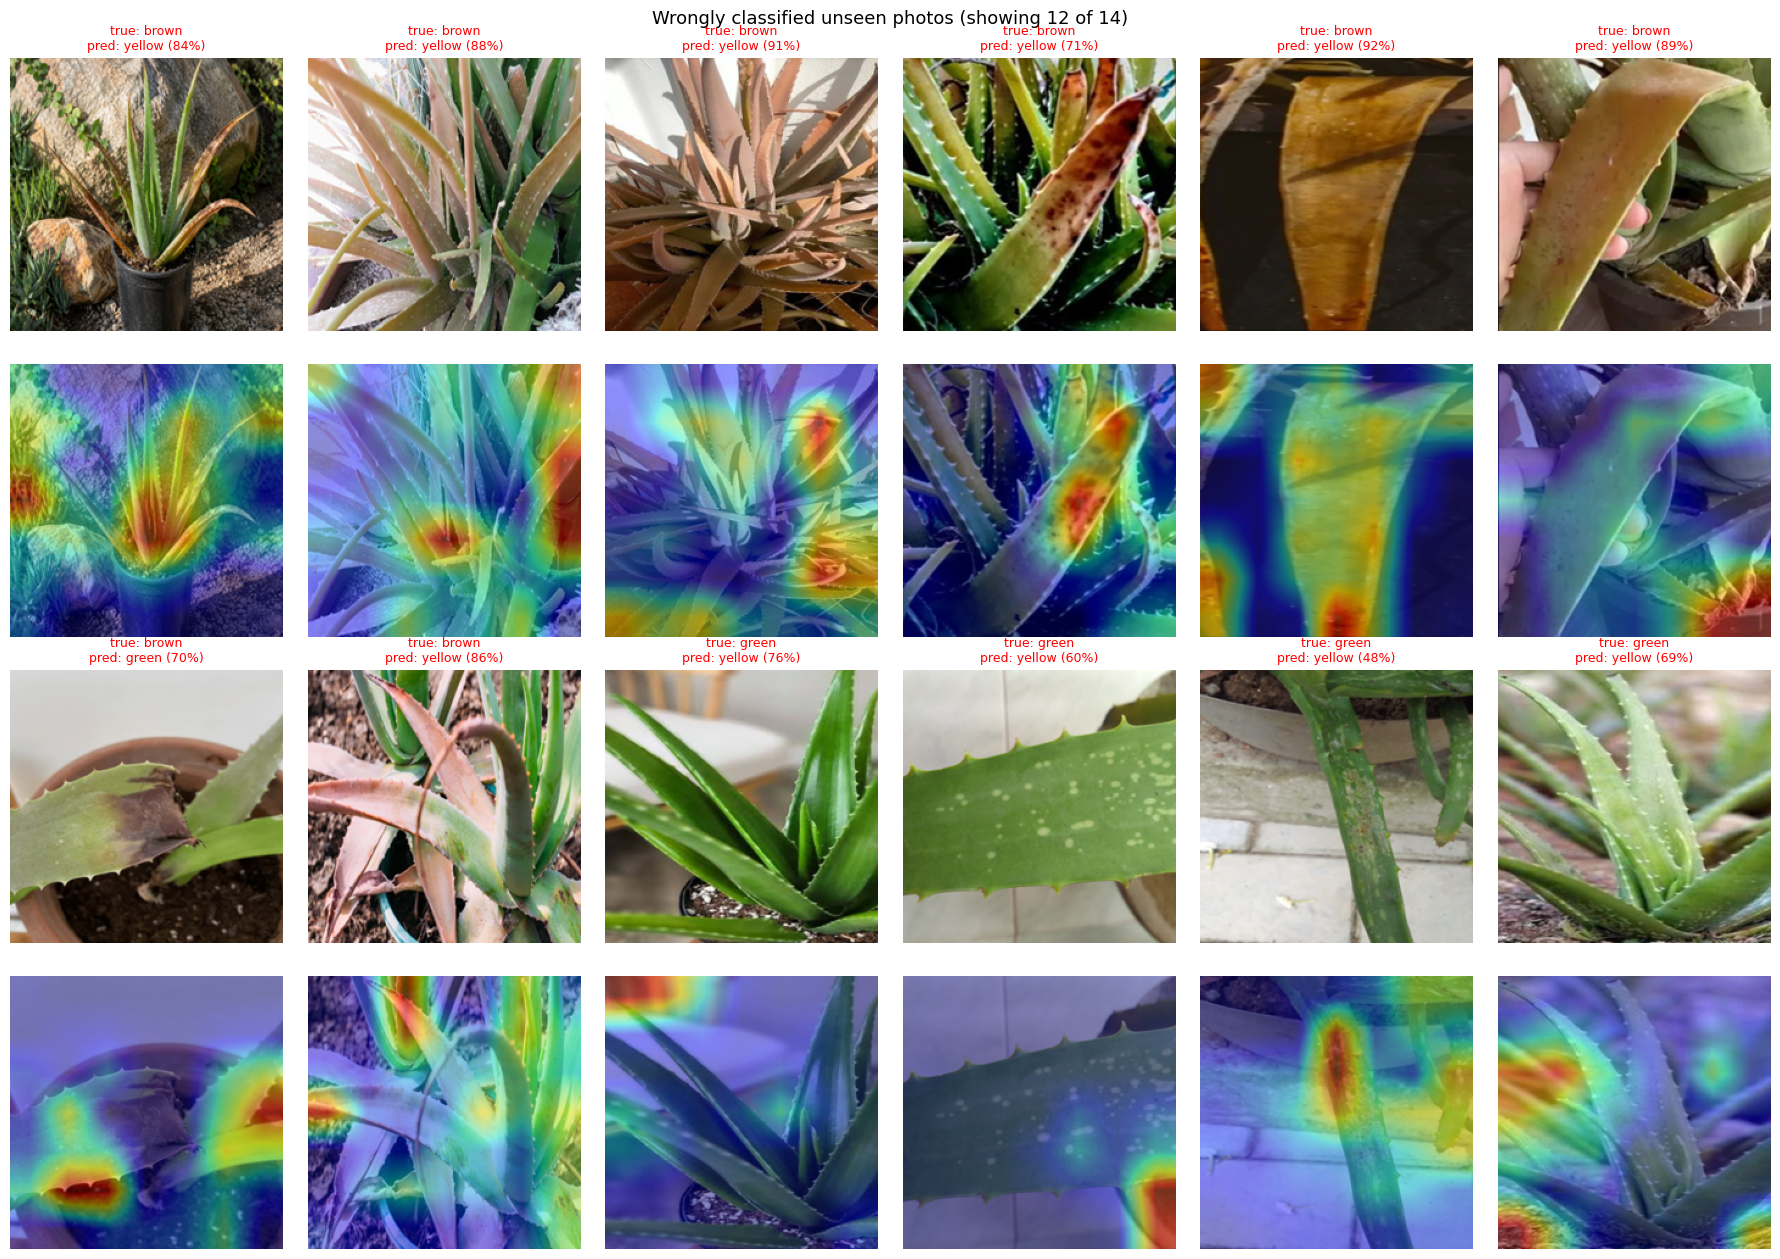

In [8]:
wrong = [i for i in range(len(un_paths)) if y_u[i] != pred_u[i]]
if not wrong:
    print("No wrong predictions.")
else:
    def gradcam(a):
        x = eval_tf(Image.fromarray(a))[None].to(DEVICE).contiguous(memory_format=torch.channels_last)
        with torch.no_grad():
            feats = model.forward_features(x)
        feats = feats.detach().float().requires_grad_(True)
        with torch.enable_grad():
            logits = model.forward_head(feats)
            cls = int(logits.argmax(1))
            model.zero_grad(); logits[0, cls].backward()
        w = feats.grad.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((w * feats).sum(1, keepdim=True))
        cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)[0, 0]
        return (cam / (cam.max() + 1e-8)).detach().cpu().numpy(), cls

    show = wrong[:12]
    cols = min(6, len(show)); rows = math.ceil(len(show) / cols)
    fig, axes = plt.subplots(rows * 2, cols, figsize=(3 * cols, 6.4 * rows), squeeze=False)
    for ax in axes.ravel(): ax.axis("off")
    for k, i in enumerate(show):
        r, c = (k // cols) * 2, k % cols
        img = np.asarray(Image.fromarray(arr_u[i]).resize((IMG_SIZE, IMG_SIZE)))
        cam, cls = gradcam(arr_u[i])
        axes[r][c].imshow(img)
        axes[r][c].set_title(f"true: {CLASSES[y_u[i]]}\npred: {CLASSES[pred_u[i]]} ({conf[i] * 100:.0f}%)", fontsize=9, color="red")
        axes[r + 1][c].imshow(img); axes[r + 1][c].imshow(cam, cmap="jet", alpha=0.45)
    fig.suptitle(f"Wrongly classified unseen photos (showing {len(show)} of {len(wrong)})", fontsize=13)
    plt.tight_layout(); plt.show()

In [9]:
import cv2
from sklearn.ensemble import RandomForestClassifier

PER_CLASS = 400

def features(path):
    img = cv2.imread(str(path))
    if img is None:
        return None
    hsv = cv2.cvtColor(cv2.resize(img, (128, 128)), cv2.COLOR_BGR2HSV)
    H, S, V = [hsv[..., i].astype(float).ravel() for i in range(3)]
    keep = (V > 50) & (S > 40)                      # ignore dark and grey pixels
    if keep.sum() < 100: keep = V > 30
    if keep.sum() == 0: keep = np.ones_like(V, dtype=bool)
    H, S, V = H[keep], S[keep], V[keep]
    return [np.median(H), H.mean(), H.std(), np.percentile(H, 25), np.percentile(H, 75),
            np.median(S), np.median(V),
            (H < 15).mean(), ((H >= 15) & (H < 35)).mean(), ((H >= 35) & (H < 90)).mean(), (H >= 90).mean()]

def feats_for(paths, labels, per_class=None):
    rng = random.Random(SEED)
    X, y = [], []
    for c in CLASSES:
        idx = [i for i, l in enumerate(labels) if l == c]
        if per_class and len(idx) > per_class:
            idx = rng.sample(idx, per_class)
        for i in idx:
            f = features(paths[i])
            if f is not None:
                X.append(f); y.append(c)
    return np.array(X), np.array(y)

baseline_acc = None
if TRAIN_DIR is None:
    print("Training dataset not attached: baseline skipped.")
else:
    tr_paths, tr_labels = list_images(TRAIN_DIR)
    X_tr, yb_tr = feats_for(tr_paths, tr_labels, PER_CLASS)
    X_un, yb_un = feats_for(un_paths, un_labels)
    print("Median hue per class (training | unseen)   [green ~35-85, yellow ~20-35, brown < 20]")
    for c in CLASSES:
        if (yb_un == c).any():
            print(f"  {c:8s} {np.median(X_tr[yb_tr == c][:, 0]):6.1f} | {np.median(X_un[yb_un == c][:, 0]):6.1f}")
    rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=SEED).fit(X_tr, yb_tr)
    pred_rf = rf.predict(X_un)
    baseline_acc = accuracy_score(yb_un, pred_rf)
    print(f"\nBASELINE on UNSEEN photos: accuracy {baseline_acc * 100:.2f}% | macro F1 {f1_score(yb_un, pred_rf, average='macro', zero_division=0):.3f}\n")
    print(classification_report(yb_un, pred_rf, labels=CLASSES, digits=3, zero_division=0))
    print("confusion matrix (rows = true, columns = predicted):", CLASSES)
    print(confusion_matrix(yb_un, pred_rf, labels=CLASSES))

Training dataset not attached: baseline skipped.


In [10]:
print("================ SUMMARY (unseen photos) ================")
print(f"model    : {Path(MODEL_PATH).name}  ({ckpt['model_name']})")
print(f"photos   : {len(un_paths)}")
print(f"accuracy : {unseen_acc * 100:.2f}%")
print(f"macro F1 : {unseen_f1:.3f}")
try:
    print(f"baseline : {baseline_acc * 100:.2f}% (colour statistics + random forest)")
except Exception:
    pass

================ SUMMARY (unseen photos) ================
model    : colour_tresnet_m.pt  (tresnet_m.miil_in21k_ft_in1k)
photos   : 32
accuracy : 56.25%
macro F1 : 0.418
